In [1]:
import logging
# Configuration du logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

In [2]:
import HBPy
from HBPy.Molecule.Crystal import Crystal,Atom

/home/bulou/venv/ATOMOD/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [3]:
status={
        'abtem':True,
        'feff':True,
        'atomic probability map':True,
        'optimization':False,
    }
config={
       'root_dir':'simul',
          'train':{
            'TEM_img_dir':"train/images",  # répertoire de stockage des images TEM
            'prob_maps_img_dir':"train/prob_maps"  # répertoire de stockage des images TEM
        },
 
    'structure':{
         'optimization':status['optimization'],
    'composition':['Pt','Co','Au'],
    'radius':5.0,
    'a':0.5*(3.55+3.92),
    },
     'nvaccum':2.0,
    'image':{
     'xmin':0.0,
     'xmax':0.0,
     'ymin':0.0,
     'ymax':0.0
    },
   'atomic presence probability map':{
            'ninter':{ # nombre d'intervalles entre deux positions atomiques
                'x':20,
                'y':20,
                'z':2
            },
         'sigma': .6  # en Å, largeur de la gaussienne ~ rayon atomique ou un peu moins
   },
            'atomic probability map':{
            'status':status['atomic probability map']
        },
           'abtem':{
            'status':status['abtem'],
            'dx':0.04,
            'dy':0.04,
            'dz':4.08/2,
            'energy':300e3,
            'focal spread':40,
            'semiangle cutoff':20,
            'defocus':200,
            'cell scale':1.1
            },
 }

_______________________________________
# Etape 1 : construire la nanoparticules
 _______________________________________
#   Etape 1.1 : la structure

In [4]:
NP=Crystal()
NP.build(a=config['structure']['a'],
    radius=config['structure']['radius'],
    materials='NP')
NP.origin_at_mass_center()
logger.info(f"min={NP.qmin} max={NP.qmax}")
logger.info(f"Mass center={NP.MC}")
logger.info(f"Number of atoms={len(NP.atoms)}")

2026-06-12 11:31:05,092 [INFO] - <module>() - min=[-4.66875 -4.66875 -4.66875] max=[4.66875 4.66875 4.66875]
2026-06-12 11:31:05,094 [INFO] - <module>() - Mass center=[-1.98830851e-15 -2.50304827e-15 -1.59468398e-15]
2026-06-12 11:31:05,095 [INFO] - <module>() - Number of atoms=44


 #   Etape 1.2 : la distribution chimique   

In [5]:
NP.set_composition(config['structure']['composition'])
NP.save(prefix="NP",fmt='xyz',directory=config['root_dir'])

#   Etape 1.3 : (optionnelle) l'optimisation structurale et/ou chimique

In [6]:
 if config['structure']['optimization']:
     NP.optimize_ase()

 ___________________________________________________________________
# Etape 2 : construire les cartes de probabilité de présence atomique
___________________________________________________________________

2026-06-12 11:31:05,464 [INFO] - xyz2slice() - Number of plane(s) along x: 6
2026-06-12 11:31:05,465 [INFO] - xyz2slice() - Mean interplane distancealong x: 1.8680205205205205
2026-06-12 11:31:05,467 [INFO] - xyz2slice() -  [-1.30130130e-03  1.87125876e+00  3.73246997e+00  5.60503003e+00
  7.46624124e+00  9.33880130e+00]
2026-06-12 11:31:05,781 [INFO] - xyz2slice() - Number of plane(s) along y: 6
2026-06-12 11:31:05,782 [INFO] - xyz2slice() - Mean interplane distancealong y: 1.8680205205205205
2026-06-12 11:31:05,783 [INFO] - xyz2slice() -  [-1.30130130e-03  1.87125876e+00  3.73246997e+00  5.60503003e+00
  7.46624124e+00  9.33880130e+00]
2026-06-12 11:31:06,085 [INFO] - xyz2slice() - Number of plane(s) along z: 6
2026-06-12 11:31:06,086 [INFO] - xyz2slice() - Mean interplane distancealong z: 1.8680205205205205
2026-06-12 11:31:06,087 [INFO] - xyz2slice() -  [-1.30130130e-03  1.87125876e+00  3.73246997e+00  5.60503003e+00
  7.46624124e+00  9.33880130e+00]
2026-06-12 11:31:06,088 [INFO] 

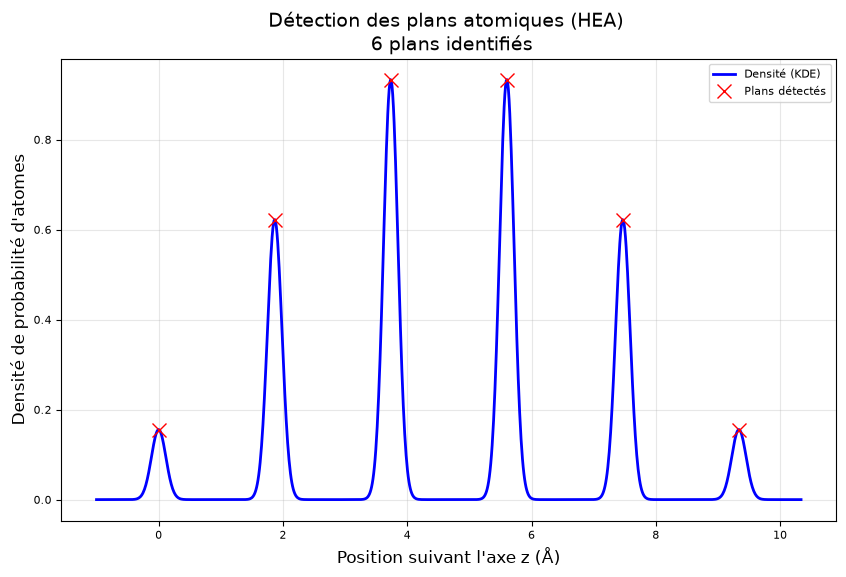

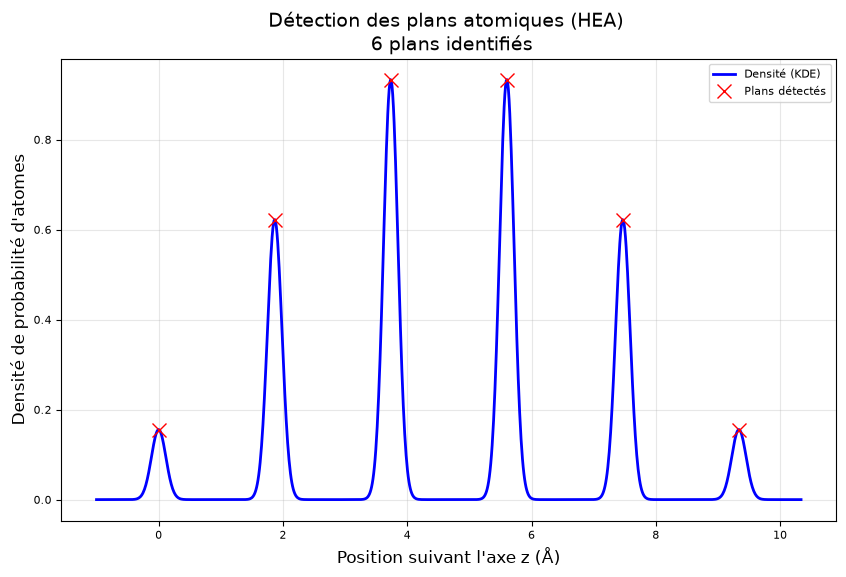

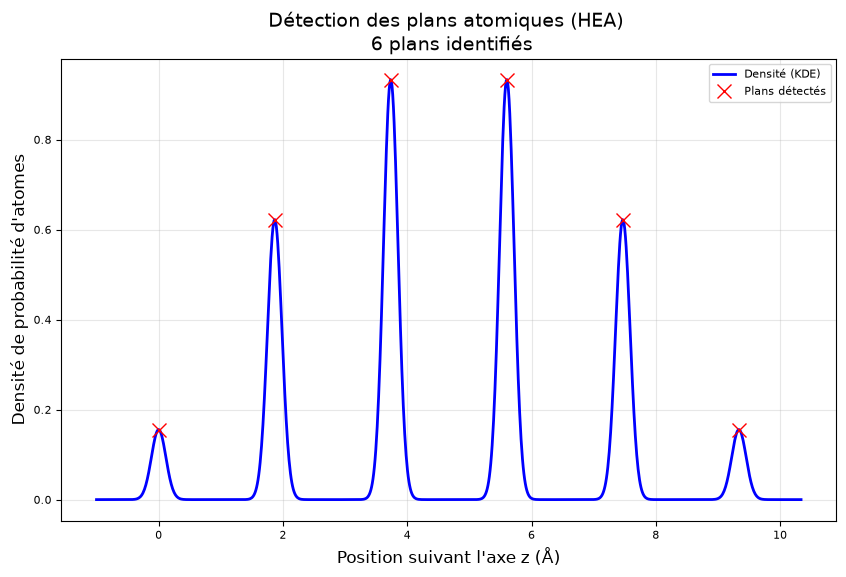

In [7]:
 if config['atomic probability map']['status']:
     NP.xyz2slice(config)
     logger.info(f"{NP.qmin[0]} {NP.qmax[0]} {NP.qmin[1]} {NP.qmax[1]}")
     logger.info(f"{config['image']['xmin']} {config['image']['xmax']} {config['image']['ymin']} {config['image']['ymax']}")


___________________________________________________________________
# Etape 3 : construire l'image TEM
    abTEM : https://github.com/abTEM/abTEM
    https://abtem.readthedocs.io/en/latest/intro.html
___________________________________________________________________
   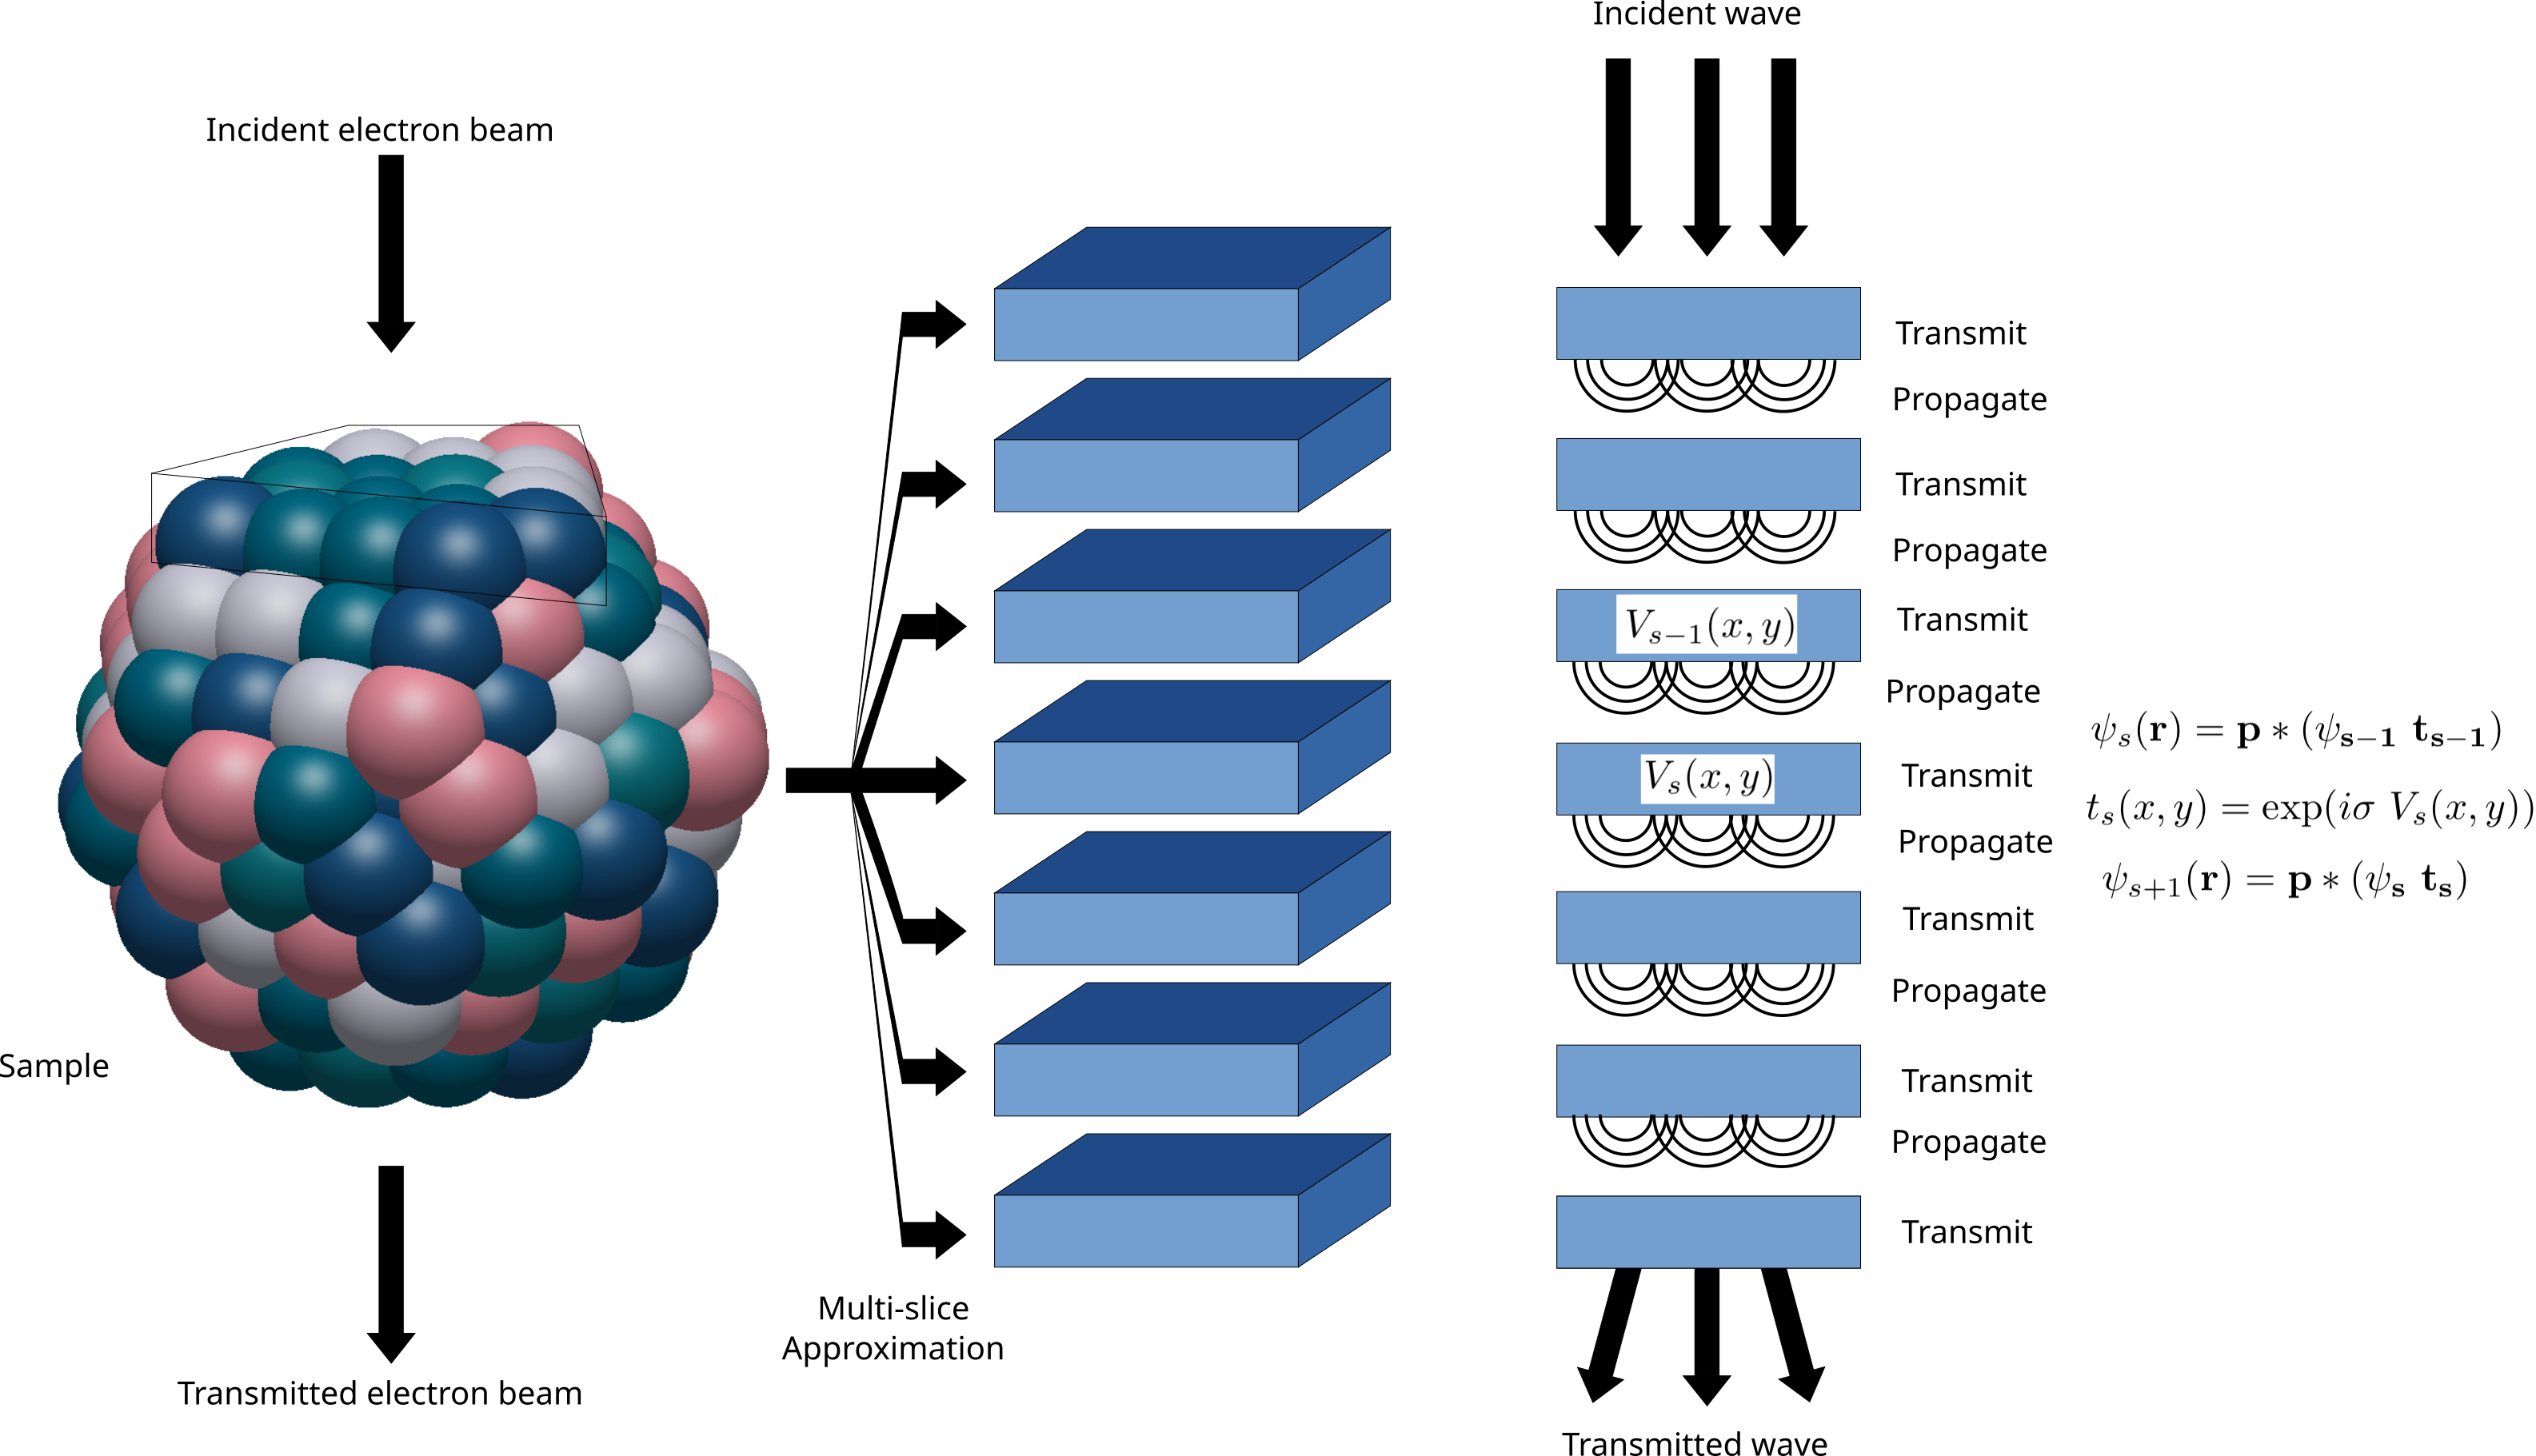

Les images TEM sont simulée dans le cadre de la méthode multislice. Le principe de cette méthode repose sur la modélisation de la diffusion des électrons à travers un échantillon (comme une nanoparticule) en suivant le formalisme mathématique de Cowley-Moodie (1957).
L'idée de base est qu'un échantillon est en général trop épais pour être traité d'un seul coup. On le découpe en tranches fines (2–5 Å), et on propage l'onde électronique tranche par tranche.
Les principales étapes de l'approche multislice sont :
1. Le découpage de l'échantillon : Le modèle atomique 3D est positionné face au faisceau d'électrons incident, puis il est virtuellement découpé en une série de tranches parallèles très fines, perpendiculaires à l'axe de propagation du faisceau (l'axe z). L'épaisseur de ces tranches est généralement définie autour de 0.2 nm (ou 2 Å)
2. L'interaction tranche par tranche : Chaque tranche est considérée mathématiquement comme un réseau de phase. La méthode calcule le potentiel électrostatique projeté pour chaque tranche, ce qui définit sa fonction de transmission.
3. La propagation itérative : L'interaction entre l'onde électronique et la matière est calculée de manière récursive. La fonction d'onde de l'électron traverse la première tranche (transmission), puis l'algorithme calcule sa propagation (propagation de Fresnel) jusqu'à la tranche suivante, et ainsi de suite jusqu'à traverser entièrement l'échantillon

Nous utilisons abTEM, un package Python open-source qui simule des images de microscopie électronique en transmission (TEM/STEM) à partir de structures atomiques.



2026-06-12 11:31:12,664 [INFO] - abTEM() - TEM images directory = simul/train/images
2026-06-12 11:31:12,667 [INFO] - abTEM() - Cell size: 16.80958208208208
2026-06-12 11:31:12,671 [INFO] - abTEM() - slice_thickness= 2.04  sampling=0.04
2026-06-12 11:31:12,674 [INFO] - abTEM() - potential extansion: (16.80958208208208, 16.80958208208208)
2026-06-12 11:31:12,675 [INFO] - abTEM() - potential origin: (0.0, 0.0, 0.0)
2026-06-12 11:31:12,676 [INFO] - abTEM() - potential shape: (9, 421, 421)


[########################################] | 100% Completed | 3.36 ss


2026-06-12 11:31:16,115 [INFO] - abTEM() - sampling=(0.039927748413496625, 0.039927748413496625)
2026-06-12 11:31:16,116 [INFO] - abTEM() - extent=(16.80958208208208, 16.80958208208208)
2026-06-12 11:31:16,117 [INFO] - abTEM() - gpts=(421, 421)


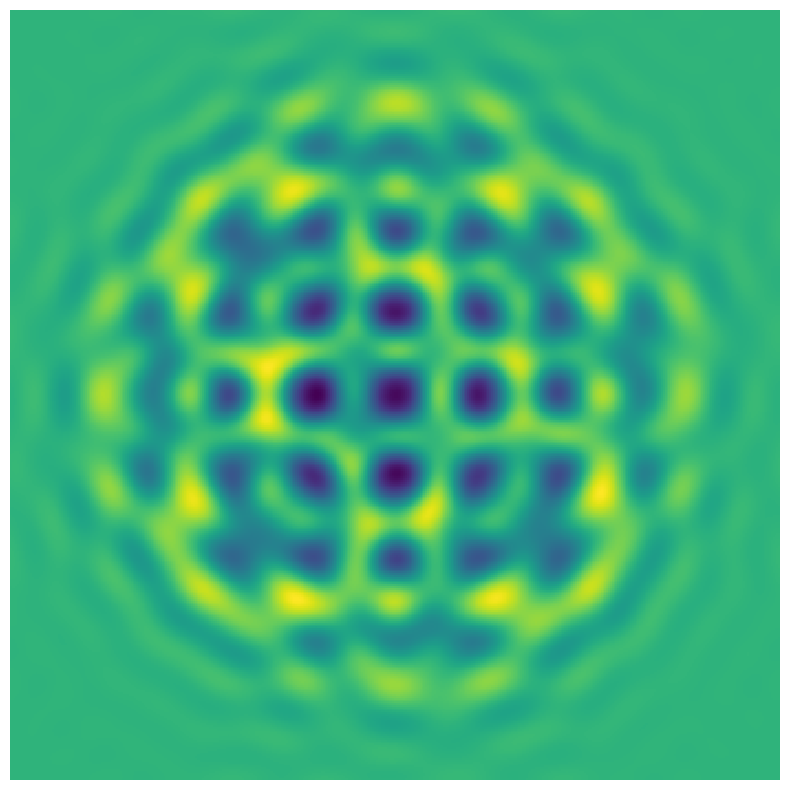

In [8]:
if config['abtem']['status']:
        NP.abTEM(config)
